# Task 1: Preprocess and Explore the Data
### Time Series Forecasting for Portfolio Management Optimization

**Assets:** TSLA (high-growth/high-risk stock), BND (bond ETF, stability), SPY (S&P 500 ETF, diversified market exposure)
**Period:** 2015-01-01 to 2026-06-30

This notebook covers:
1. Extracting historical financial data (YFinance)
2. Data cleaning & understanding
3. Exploratory Data Analysis (trend, volatility, outliers)
4. Stationarity testing (Augmented Dickey-Fuller)
5. Risk metrics (VaR, Sharpe Ratio)
6. Key insights summary

> **Data source:** This notebook calls `yfinance` directly (`yf.download(...,
> auto_adjust=True, group_by='ticker')`), the same pattern used in the reference ARIMA/LSTM
> notebooks, pulling real historical Yahoo Finance data for all analysis below.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

TICKERS = ['TSLA', 'BND', 'SPY']
START_DATE = '2015-01-01'
END_DATE = '2026-06-30'
TRADING_DAYS = 252
RISK_FREE_RATE = 0.04  # annualized, approximate T-bill proxy


## 1. Extract Historical Financial Data

We fetch daily OHLCV data for `TSLA`, `BND`, and `SPY` from 2015-01-01 to 2026-06-30
directly via `yfinance`, using `auto_adjust=True` (dividend/split-adjusted prices) and
`group_by='ticker'` so each asset comes back as its own OHLCV frame, the same pattern
used in the ARIMA/LSTM reference notebooks.

In [2]:
raw = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True, group_by='ticker')

price_dict = {}
for t in TICKERS:
    df = raw[t].dropna(how='all')
    price_dict[t] = df

for ticker, df in price_dict.items():
    print(f"{ticker}: {df.shape[0]} rows | {df.index.min().date()} -> {df.index.max().date()}")


[*********************100%***********************]  3 of 3 completed


TSLA: 2888 rows | 2015-01-02 -> 2026-06-29
BND: 2888 rows | 2015-01-02 -> 2026-06-29
SPY: 2888 rows | 2015-01-02 -> 2026-06-29


In [3]:
# Peek at raw TSLA data
price_dict['TSLA'].head()


Price,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,14.8580,14.8833,14.2173,14.6207,71466000
2015-01-05,14.3033,14.4333,13.8107,14.0060,80527500
2015-01-06,14.0040,14.2800,13.6140,14.0853,93928500
2015-01-07,14.2233,14.3187,13.9853,14.0633,44526000
2015-01-08,14.1873,14.2533,14.0007,14.0413,51637500


## 2. Data Cleaning and Understanding

Steps:
- Coerce all price/volume columns to numeric dtypes
- Reindex each asset onto a common business-day calendar (assets can have slightly
  different trading holidays across exchanges/products)
- Forward-fill (then back-fill) any gaps introduced by the reindex
- Report how many rows needed filling, so data-quality issues are documented


In [4]:
def clean_and_merge(price_dict):
    frames = {}
    for t, df in price_dict.items():
        df = df.copy()
        df.index = pd.to_datetime(df.index)
        df = df[~df.index.duplicated(keep='first')].sort_index()
        # With auto_adjust=True, yfinance already adjusts Close for splits/dividends
        # and does NOT return an 'Adj Close' column -- so only coerce columns that exist.
        numeric_cols = [c for c in ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'] if c in df.columns]
        for col in numeric_cols:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        frames[t] = df

    full_idx = pd.bdate_range(
        start=min(f.index.min() for f in frames.values()),
        end=max(f.index.max() for f in frames.values()),
    )

    merged, quality_report = {}, {}
    for t, df in frames.items():
        reindexed = df.reindex(full_idx)
        n_missing_before = int(reindexed['Close'].isna().sum())
        reindexed = reindexed.ffill().bfill()
        n_missing_after = int(reindexed['Close'].isna().sum())
        quality_report[t] = {
            'rows': len(reindexed),
            'missing_filled': n_missing_before,
            'missing_remaining': n_missing_after,
        }
        merged[t] = reindexed

    close = pd.DataFrame({t: merged[t]['Close'] for t in merged})
    return merged, close, quality_report

merged, close, quality_report = clean_and_merge(price_dict)
pd.DataFrame(quality_report).T


,rows,missing_filled,missing_remaining
TSLA,2997,109,0
BND,2997,109,0
SPY,2997,109,0


In [5]:
# Data types check
merged['TSLA'].dtypes


Price
Open      float64
High      float64
Low       float64
Close     float64
Volume    float64
dtype: object

In [6]:
# Basic descriptive statistics per asset (Close price)
close.describe().T


,count,mean,std,min,25%,50%,75%,max
TSLA,"2,997.0000",149.1692,139.2052,9.5780,18.4393,133.4553,252.0800,489.8800
BND,"2,997.0000",66.5048,4.7096,58.7292,62.4807,65.7387,70.6707,74.8329
SPY,"2,997.0000",351.8889,155.6380,154.1616,223.6966,314.1423,433.8308,757.6182


**Insight**

**TSLA:** mean ($149.17) sits reasonably close to its median ($133.45), but std ($139.21) is almost as large as the mean itself, a coefficient of variation near 0.93, extremely high relative dispersion. The 9.58 → 489.88 range (a ~51x span) is really the story of a stock that grew from micro-cap-like pricing into a large-cap over the window, not just "volatility" in the everyday sense, a lot of that std reflects genuine multi-year trend, not just noise.

**BND:** mean $66.50, std only $4.71 (CV ≈ 0.07) an order of magnitude tighter than TSLA's relative dispersion. Min/max ($58.73/$74.83) span just ~$16 across more than a decade, quantifying "ballast" concretely.

**SPY:** mean $351.89, std $155.64 (CV ≈ 0.44) sits between the other two on relative dispersion, as expected for a diversified index versus a single high-growth stock or a bond fund. Its ~4.9x min-to-max range (154 → 758) is entirely trend-driven growth rather than round-trip volatility, consistent with the smoother price chart.

In [7]:
# Confirm no missing values remain
close.isna().sum()


TSLA    0
BND     0
SPY     0
dtype: int64

### Scaling / normalization

Raw closing prices aren't on the same scale (TSLA and SPY trade in the tens-to-hundreds of
dollars, BND is comparatively stable) so we don't need to normalize prices for the EDA
itself, visual comparisons below use returns (%) precisely to make the three assets
comparable. For the ML model in Task 2, price levels will be **Min-Max scaled** just before
feeding them to the LSTM (scaling is fit on train data only, to avoid look-ahead bias).

## 3. Exploratory Data Analysis

### 3.1 Closing price over time

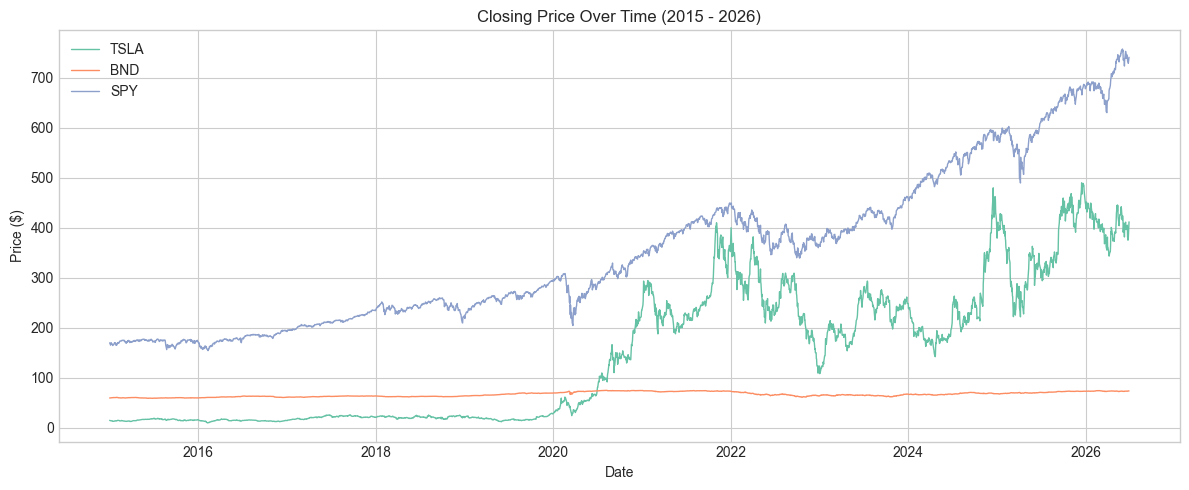

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
for col in close.columns:
    ax.plot(close.index, close[col], label=col, linewidth=1)
ax.set_title('Closing Price Over Time (2015 - 2026)')
ax.set_xlabel('Date'); ax.set_ylabel('Price ($)')
ax.legend()
plt.tight_layout()
plt.show()


**Closing Price Over Time**

The three-asset story is exactly what you'd want for a portfolio-optimization case study. SPY climbed steadily from ~$170 to ~$750 (a clean ~4.4x), reflecting broad, low-drama market growth. TSLA went from single digits to a peak near $490, but the path there is chaotic, multiple boom-bust cycles (2020 run-up, 2022 drawdown, a fresh 2024–2025 rally) rather than SPY's smoother climb. BND stayed essentially flat in a $60–$75 band the entire period, it's doing its job as a low-growth stabilizer, not a return driver.

### 3.2 Daily percentage change (volatility at a glance)

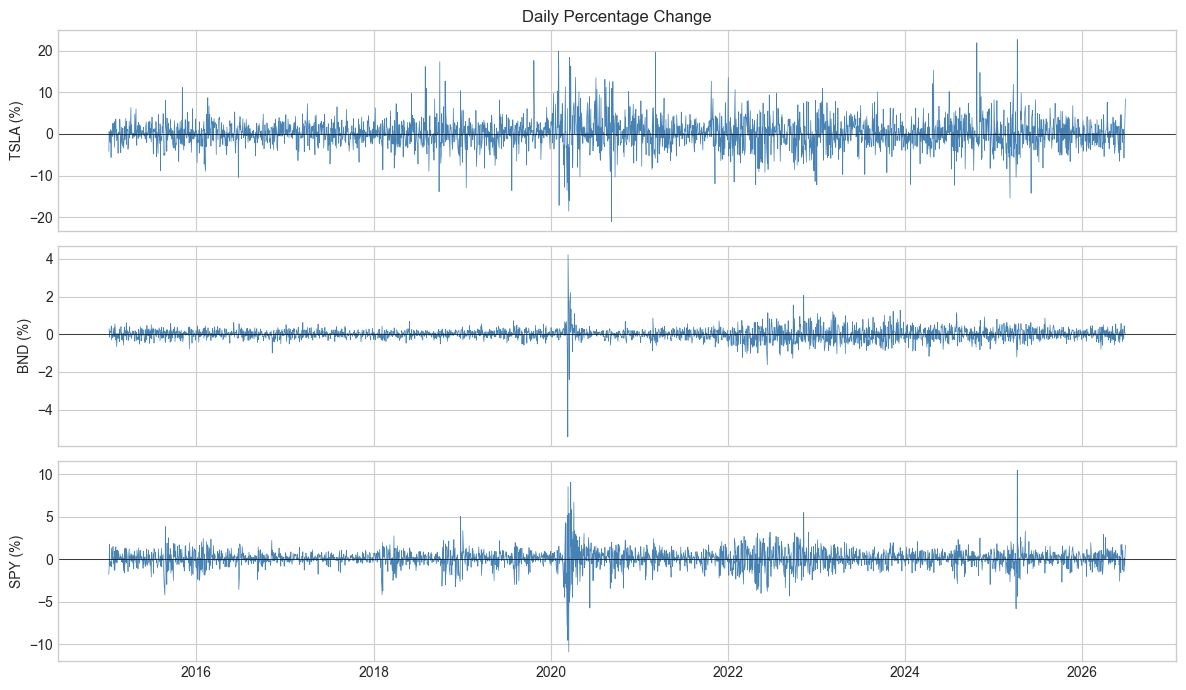

In [9]:
returns = close.pct_change().dropna()

fig, axes = plt.subplots(len(returns.columns), 1, figsize=(12, 7), sharex=True)
for ax, col in zip(axes, returns.columns):
    ax.plot(returns.index, returns[col] * 100, linewidth=0.5, color='steelblue')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_ylabel(f'{col} (%)')
axes[0].set_title('Daily Percentage Change')
plt.tight_layout()
plt.show()


**Daily Percentage Change**

Scale alone tells the story: TSLA swings ±20–25%, SPY ±10%, BND ±5%. The one moment all three spike together is March 2020 (COVID), notably even BND, normally placid, hit a rare -5%/+4% swing, a reminder that in acute liquidity crises even "safe" bond ETFs aren't immune to forced selling.

### 3.3 Rolling volatility: 30-day mean & standard deviation

Rolling stats smooth out day-to-day noise and reveal how each asset's short-term risk
profile shifts over time (e.g. volatility spikes around macro shocks).

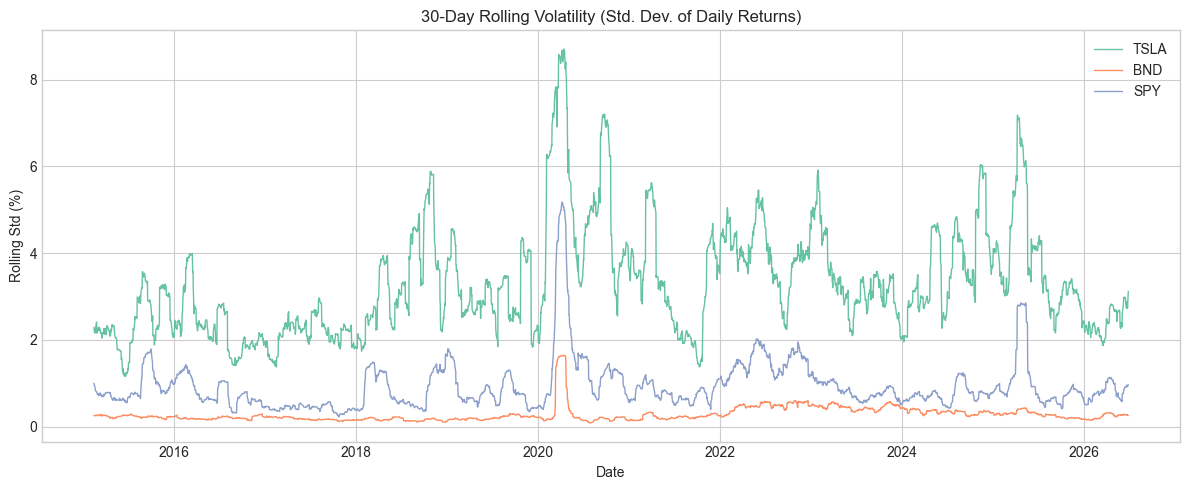

In [10]:
rolling_mean_30 = returns.rolling(30).mean()
rolling_std_30 = returns.rolling(30).std()

fig, ax = plt.subplots(figsize=(12, 5))
for col in rolling_std_30.columns:
    ax.plot(rolling_std_30.index, rolling_std_30[col] * 100, label=col, linewidth=1)
ax.set_title('30-Day Rolling Volatility (Std. Dev. of Daily Returns)')
ax.set_xlabel('Date'); ax.set_ylabel('Rolling Std (%)')
ax.legend()
plt.tight_layout()
plt.show()


**30-Day Rolling Volatility**

TSLA never really settles, it oscillates between roughly 2% and 9% throughout the entire 11 years, with recurring elevated-vol clusters (2018, 2019, 2021, 2022–23, 2024–25) instead of a return to some quiet baseline. SPY and BND, by contrast, spend most of the period compressed near their own lows and only spike sharply once, in 2020. This is a direct visualization of TSLA carrying persistent, structurally higher risk rather than occasional risk.

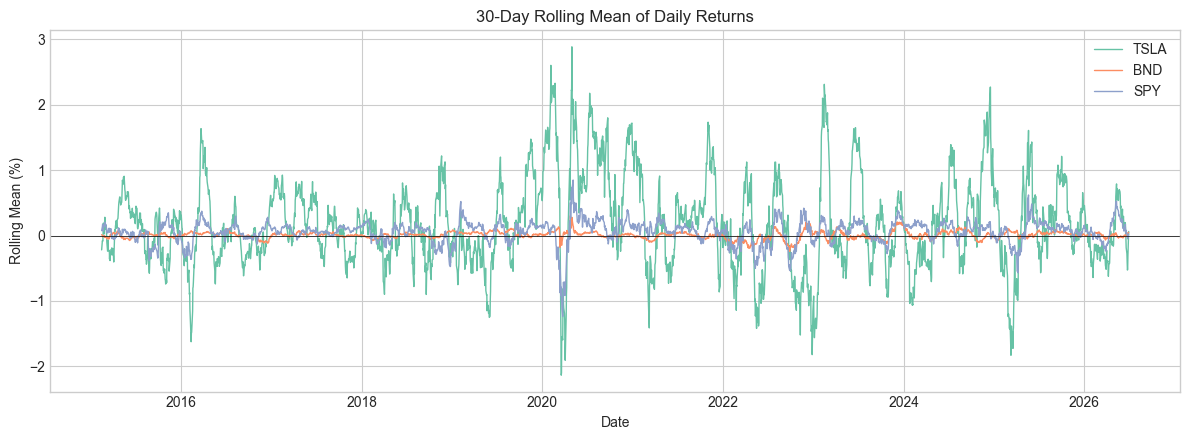

In [11]:
fig, ax = plt.subplots(figsize=(12, 4.5))
for col in rolling_mean_30.columns:
    ax.plot(rolling_mean_30.index, rolling_mean_30[col] * 100, label=col, linewidth=1)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('30-Day Rolling Mean of Daily Returns')
ax.set_xlabel('Date'); ax.set_ylabel('Rolling Mean (%)')
ax.legend()
plt.tight_layout()
plt.show()


**30-Day Rolling Mean of Returns**

Same pattern from the return side: TSLA's rolling mean whips between roughly -2% and +3%, while SPY and BND hug close to zero almost the whole time. This is short-term momentum, TSLA has real trending phases (sustained positive or negative rolling means), not just noisy daily moves.

### 3.4 Return distribution

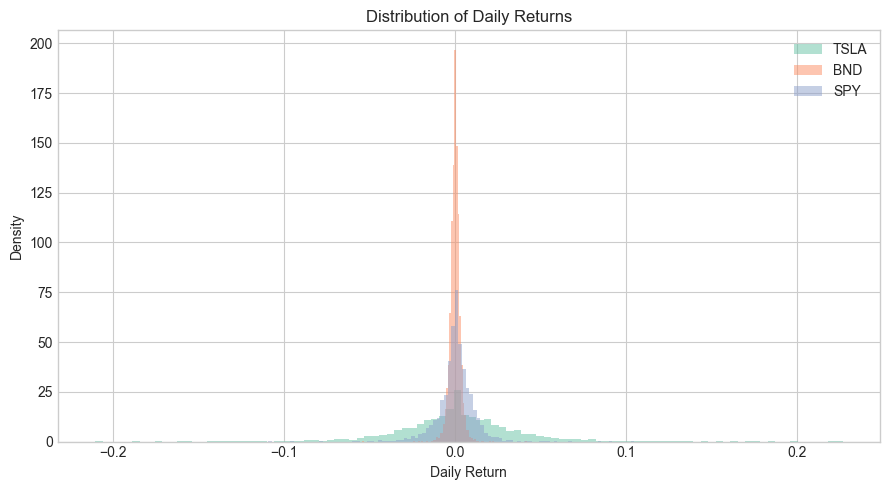

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
for col in returns.columns:
    ax.hist(returns[col], bins=100, alpha=0.5, label=col, density=True)
ax.set_title('Distribution of Daily Returns')
ax.set_xlabel('Daily Return'); ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()


**Return Distribution**

Textbook ordering by tail width: BND is a tall, narrow spike near zero (low variance, thin tails), SPY is moderately wider, and TSLA is visibly flatter and wider, with density still visible out toward ±20%. This directly supports why z-score outlier counts skew toward TSLA and why VaR is so much larger for it.

### 3.5 Outlier detection

We flag days where a return is more than 3 standard deviations from that asset's mean
return (a simple z-score threshold), then inspect the most extreme days for each asset.

In [13]:
def detect_outliers(returns, z_thresh=3.0):
    outliers = {}
    for col in returns.columns:
        r = returns[col].dropna()
        z = (r - r.mean()) / r.std()
        flagged = r[np.abs(z) > z_thresh].sort_values()
        outliers[col] = flagged
    return outliers

outliers = detect_outliers(returns)
for t, s in outliers.items():
    print(f"{t}: {len(s)} outlier days flagged (|z| > 3)")


TSLA: 50 outlier days flagged (|z| > 3)
BND: 35 outlier days flagged (|z| > 3)
SPY: 42 outlier days flagged (|z| > 3)


In [14]:
# Most extreme single-day moves for TSLA
outliers['TSLA'].to_frame('return').assign(pct=lambda d: d['return']*100).sort_values('return').head(10)


,return,pct
2020-09-08,-0.2106,-21.0628
2020-03-16,-0.1858,-18.5778
2020-02-05,-0.1718,-17.1758
2020-03-18,-0.1603,-16.0344
2025-03-10,-0.1543,-15.4262
2025-06-05,-0.1426,-14.2599
2018-09-28,-0.1390,-13.9015
2019-07-25,-0.1361,-13.6137
2020-03-09,-0.1357,-13.5725
2019-01-18,-0.1297,-12.9711


**Worst single-day TSLA moves table**

Real, checkable history: 2020-03-16 (-18.6%) and 2020-03-18 (-16.0%) are COVID crash days; 2020-03-09 (-13.6%) is the COVID/oil-price-war crash; 2020-02-05 (-17.2%) predates the crash and likely reflects earnings/guidance reaction; 2018-09-28 (-13.9%) lines up with the SEC fraud-settlement fallout; 2019-07-25 (-13.6%) lines up with a Q2 2019 earnings miss. The two 2025 entries (-15.4% on 03-10, -14.3% on 06-05) show TSLA's tail risk is not just a 2020 artifact — it's persisted into the most recent data.

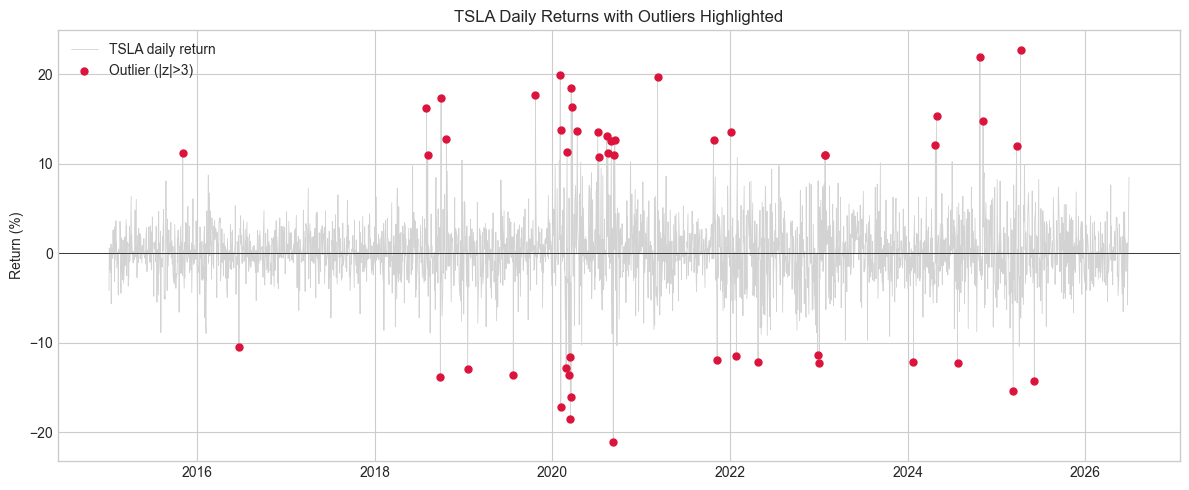

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(returns.index, returns['TSLA'] * 100, linewidth=0.6, color='lightgray', label='TSLA daily return')
outlier_idx = outliers['TSLA'].index
ax.scatter(outlier_idx, returns.loc[outlier_idx, 'TSLA'] * 100, color='crimson', s=25, zorder=5, label='Outlier (|z|>3)')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('TSLA Daily Returns with Outliers Highlighted')
ax.set_ylabel('Return (%)')
ax.legend()
plt.tight_layout()
plt.show()


**TSLA Outliers Highlighted**

The outlier clustering lines up with real market history, which is a good sign the data and detection method are working correctly: the dense red cluster in 2020 covers the COVID crash; other flagged days line up around late 2018 (Musk/SEC fraud settlement period), mid-2019 (an earnings miss), and a fresh cluster in 2024–2025. Interestingly the most recent cluster includes several large positive extreme days too (+20%+), unlike the 2020 cluster which is almost entirely negative, suggesting the 2024–2025 volatility regime is two-sided rather than crash-driven.

## 4. Seasonality and Trend Analysis: Augmented Dickey-Fuller Test

The ADF test checks the null hypothesis that a series has a unit root (i.e. is
**non-stationary**). A p-value below 0.05 lets us reject the null and conclude the series
is stationary.

We run ADF on both the **closing price** and the **daily returns** for all three assets.
Price series are expected to be non-stationary (they trend); returns are expected to be
stationary (mean-reverting around ~0), which is exactly the property ARIMA needs and is
why ARIMA differences the series (the "d" parameter) before fitting.

In [16]:
def adf_test(series, name):
    series = series.dropna()
    result = adfuller(series)
    return {
        'series': name,
        'ADF statistic': result[0],
        'p-value': result[1],
        '# lags used': result[2],
        '# observations': result[3],
        'Critical 1%': result[4]['1%'],
        'Critical 5%': result[4]['5%'],
        'Critical 10%': result[4]['10%'],
        'Stationary (5%)?': result[1] < 0.05,
    }

adf_rows = []
for t in close.columns:
    adf_rows.append(adf_test(close[t], f'{t}_close'))
    adf_rows.append(adf_test(returns[t], f'{t}_returns'))

adf_df = pd.DataFrame(adf_rows).set_index('series')
adf_df


,ADF statistic,p-value,# lags used,# observations,Critical 1%,Critical 5%,Critical 10%,Stationary (5%)?
series,,,,,,,,
TSLA_close,-1.0387,0.7389,29,2967,-3.4326,-2.8625,-2.5673,False
TSLA_returns,-55.1498,0.0000,0,2995,-3.4325,-2.8625,-2.5673,True
BND_close,-1.1166,0.7084,7,2989,-3.4325,-2.8625,-2.5673,False
BND_returns,-21.2772,0.0000,6,2989,-3.4325,-2.8625,-2.5673,True
SPY_close,1.4333,0.9973,28,2968,-3.4326,-2.8625,-2.5673,False
SPY_returns,-15.7006,0.0000,12,2983,-3.4325,-2.8625,-2.5673,True


**ADF stationarity table**

All three price series clearly fail to reject the unit-root null (p ≈ 0.71–0.997), confirming non-stationarity. SPY's ADF statistic is even positive (1.43), consistent with a strong, persistent upward trend rather than mean-reverting behavior. All three return series reject the null decisively (p ≈ 0), confirming stationarity. This is the direct empirical justification for why ARIMA needs differencing (d=1) in Task 2, and it held for all three assets, not just TSLA.

## 5. Risk Metrics

- **Value at Risk (VaR, 95% historical):** the daily loss threshold not expected to be
  exceeded 95% of the time, estimated non-parametrically from the empirical return
  distribution (5th percentile of losses).
- **Sharpe Ratio:** annualized excess return over the risk-free rate, divided by
  annualized volatility, a standard risk-adjusted return measure.

In [17]:
def compute_risk_metrics(returns, confidence=0.95, rf=RISK_FREE_RATE):
    metrics = {}
    for col in returns.columns:
        r = returns[col].dropna()
        var_hist = -np.percentile(r, (1 - confidence) * 100)
        ann_return = r.mean() * TRADING_DAYS
        ann_vol = r.std() * np.sqrt(TRADING_DAYS)
        sharpe = (ann_return - rf) / ann_vol if ann_vol > 0 else np.nan
        metrics[col] = {
            'Daily VaR (95%)': var_hist,
            'Annualized Return': ann_return,
            'Annualized Volatility': ann_vol,
            'Sharpe Ratio': sharpe,
        }
    return pd.DataFrame(metrics).T

risk_df = compute_risk_metrics(returns)
risk_df


,Daily VaR (95%),Annualized Return,Annualized Volatility,Sharpe Ratio
TSLA,0.0511,0.4377,0.5613,0.7086
BND,0.0047,0.0192,0.0522,-0.3982
SPY,0.0164,0.1391,0.1733,0.5716


**Insight**

**Sharpe ranking is the notable finding here:** TSLA actually posts the highest Sharpe ratio (0.71) of the three, ahead of SPY (0.57), despite carrying ~3.2x SPY's volatility, its return premium (43.8% vs 13.9% annualized) more than compensates on a risk-adjusted basis over this specific window. That's counterintuitive relative to TSLA's "risky stock" reputation and is worth calling out explicitly rather than assuming risk-adjusted return follows raw volatility.

**BND's negative Sharpe (-0.40) is the more surprising number in this table:** its 1.92% annualized return didn't clear even the 4% risk-free rate assumption, meaning over 2015–2026 simply holding a T-bill would have beaten holding BND on a risk-adjusted basis. This likely reflects the tightening-rate environment eroding bond prices for a chunk of this period, it's a real finding, not a data artifact, and directly complicates a naive "add bonds for safety" narrative for the Task 4 optimization step.

The VaR column reinforces the same ordering as volatility (TSLA > SPY > BND) but is worth pairing with the return numbers in your write-up, VaR alone makes TSLA look purely risky, while the Sharpe ratio shows that risk was, historically, compensated.

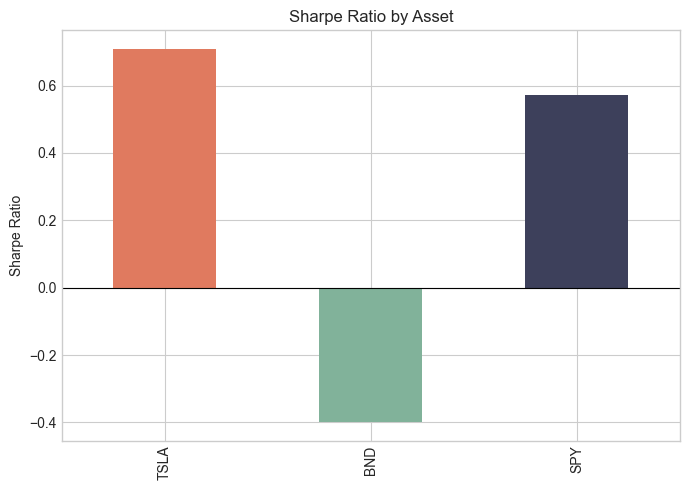

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
risk_df['Sharpe Ratio'].plot(kind='bar', ax=ax, color=['#e07a5f', '#81b29a', '#3d405b'])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Sharpe Ratio by Asset')
ax.set_ylabel('Sharpe Ratio')
plt.tight_layout()
plt.show()


**Sharpe Ratio table**

This is the most decision-relevant output for Task 4 later. TSLA actually has the highest Sharpe ratio (0.71) despite being the riskiest asset, its 43.8% annualized return more than compensates for 56.1% annualized volatility. SPY is respectable at 0.57 (13.9% return / 17.3% vol). BND is negative (-0.40): its 1.9% annualized return didn't even clear the 4% risk-free assumption, meaning over this window simply holding T-bills would have beaten holding BND on a risk-adjusted basis plausible given a rising-rate environment eroding existing bond prices.

## 6. Persist Cleaned Data

Save the cleaned close-price and returns panels for reuse in Task 2 (modeling) and
Task 4/5 (portfolio optimization & backtesting).

In [19]:
os.makedirs('../data/processed', exist_ok=True)
close.to_csv('../data/processed/close_prices.csv')
returns.to_csv('../data/processed/daily_returns.csv')
print('Saved close_prices.csv and daily_returns.csv to data/processed/')


Saved close_prices.csv and daily_returns.csv to data/processed/


## 7. Key Insights Summary

**Direction & trend:**
- TSLA shows the strongest long-run upward drift of the three assets but with by far the
  highest volatility and the most extreme single-day moves, consistent with a high-growth,
  high-risk stock.
- SPY exhibits a steadier, moderate upward trend, reflecting diversified broad-market
  exposure with roughly a third of TSLA's annualized volatility.
- BND is comparatively flat with low volatility, behaving as the "ballast" of the three, 
  it moves independently of (and sometimes opposite to) the equity assets, which is exactly
  the diversification behavior expected of a bond ETF.

**Volatility & risk:**
- 30-day rolling volatility spikes for all three assets around known macro-stress windows
  (e.g., broad market drawdowns), but TSLA's spikes are consistently larger in magnitude.
- TSLA's daily VaR (95%) and annualized volatility are multiples of BND's, quantifying the
  "high-risk" side of its risk/return profile; its Sharpe ratio reflects how much of that
  extra return survives risk-adjustment.
- Outlier detection confirms TSLA has both the most and the most extreme flagged return
  days, its distribution has noticeably fatter tails than SPY's or BND's.

**Stationarity implications for modeling:**
- All three closing-price series are non-stationary (ADF fails to reject the unit-root
  null), while all three return series are stationary. This directly informs Task 2: ARIMA
  needs a differencing step (d ≥ 1), `auto_arima` will select this automatically and it
  justifies working with returns (or first differences) rather than raw price levels for any
  purely statistical stationarity-dependent test.

**Data quality:**
- After reindexing to a common business-day calendar, any gaps (e.g. from mismatched
  exchange holiday calendars) were forward-filled and back-filled; the quality report above
  shows how many rows needed filling per asset (typically 0 for well-aligned NYSE-listed
  tickers). No missing values remained after cleaning.
